# Personalized Movie Recommendations for a Streaming Platform

The business goal is to answer:

**Which movies or series should we recommend to each user so they watch more content and stay engaged?**


## Dataset Description
For this I used synthetic data which mimics a realistic streaming-platform dataset.

In this we have 3 tables:

### users.csv
User demographic and subscription information.

### movies.csv
Movie and series metadata.

### ratings.csv
User watch and rating behavior.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 1. Load Data

The notebook expects the CSV files in a folder called `streaming_recommendation_dataset`.

If you downloaded this notebook from ChatGPT, the dataset files are included separately.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_DIR = "/content/drive/MyDrive/Datasets/recommendation-systems/data/"

users = pd.read_csv(f"{DATA_DIR}/users.csv")
movies = pd.read_csv(f"{DATA_DIR}/movies.csv")
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")

print("Users shape:", users.shape)
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)


Users shape: (1000, 7)
Movies shape: (60, 9)
Ratings shape: (18138, 7)


In [4]:
users.head()

,user_id,age,country,subscription_plan,primary_device,favorite_genre_1,favorite_genre_2
0,1,34,USA,Basic,Laptop,Romance,Fantasy
1,2,45,Mexico,Premium,Smart TV,Animation,Sci-Fi
2,3,34,USA,Premium,Laptop,Action,Horror
3,4,52,Canada,Standard,Laptop,Comedy,Romance
4,5,57,UK,Premium,Smart TV,Thriller,Horror


In [5]:
movies.head()

,movie_id,title,primary_genre,secondary_genre,release_year,content_type,maturity_rating,duration_min,avg_platform_rating
0,101,Shadow Protocol,Comedy,Action,2019,Movie,PG,92,4.33
1,102,City of Echoes,Horror,Comedy,2024,Series,G,78,3.17
2,103,Neon Warriors,Sci-Fi,Fantasy,2024,Movie,R,100,4.29
3,104,Love in Autumn,Horror,Animation,2018,Series,R,110,4.46
4,105,The Last Algorithm,Action,Sci-Fi,2021,Series,PG-13,94,3.39


In [6]:
ratings.head()

,user_id,movie_id,watch_date,watch_time_minutes,completion_rate,rating,liked
0,1,117,2025-03-14,81.9,0.92,3,0
1,1,140,2025-05-24,74.8,0.88,5,1
2,1,143,2025-11-09,134.4,0.84,3,0
3,1,139,2025-05-06,48.6,0.60,4,1
4,1,144,2025-12-09,113.0,0.85,3,0


## 2. Basic EDA

try getting answers to:
- How many users?
- How many movies?
- Which movies are watched most?
- Which genres are popular?
- How are ratings distributed?


In [7]:
print("Unique users:", ratings["user_id"].nunique())
print("Unique movies:", ratings["movie_id"].nunique())
print("Total interactions:", len(ratings))
print("Average ratings per user:", round(ratings.groupby("user_id").size().mean(), 2))
print("Average ratings per movie:", round(ratings.groupby("movie_id").size().mean(), 2))


Unique users: 1000
Unique movies: 60
Total interactions: 18138
Average ratings per user: 18.14
Average ratings per movie: 302.3


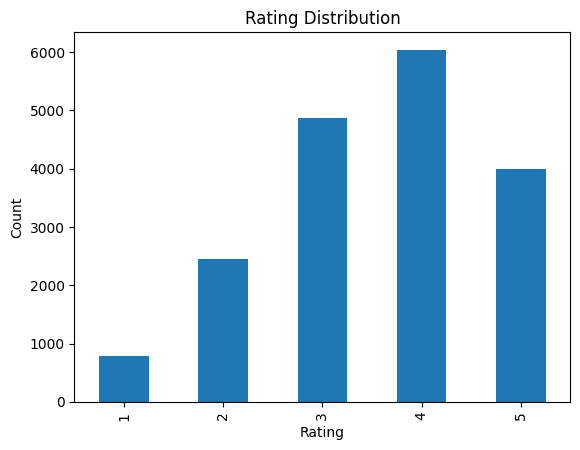

In [8]:
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


In [9]:
movie_stats = (
    ratings.groupby("movie_id")
    .agg(
        num_ratings=("rating", "count"),
        avg_rating=("rating", "mean"),
        avg_completion=("completion_rate", "mean")
    )
    .reset_index()
    .merge(movies, on="movie_id")
    .sort_values(["num_ratings", "avg_rating"], ascending=False)
)

movie_stats.head(10)


,movie_id,num_ratings,avg_rating,avg_completion,title,primary_genre,secondary_genre,release_year,content_type,maturity_rating,duration_min,avg_platform_rating
3,104,341,3.548387,0.691056,Love in Autumn,Horror,Animation,2018,Series,R,110,4.46
1,102,338,3.642012,0.680296,City of Echoes,Horror,Comedy,2024,Series,G,78,3.17
30,131,338,3.529586,0.680325,Mystery Lane,Horror,Drama,2024,Series,PG,135,4.45
58,159,337,3.534125,0.689466,Deep Sea Monsters,Animation,Romance,2019,Movie,PG-13,119,4.15
57,158,336,3.657738,0.709405,Wedding Season,Documentary,Romance,2019,Movie,PG,78,4.19
37,138,335,3.513433,0.691552,True Crime Files,Documentary,Thriller,2021,Series,PG,99,3.53
7,108,334,3.568862,0.696707,Laugh Track Live,Animation,Comedy,2023,Series,R,121,4.04
39,140,329,3.553191,0.708237,Racing Pulse,Horror,Fantasy,2017,Movie,R,85,4.53
25,126,327,3.590214,0.696055,Robot Heart,Horror,Drama,2019,Series,PG,144,4.36
5,106,324,3.574074,0.674907,Midnight Heist,Romance,Comedy,2016,Series,G,120,4.53


In [10]:
genre_stats = (
    ratings.merge(movies, on="movie_id")
    .groupby("primary_genre")
    .agg(
        total_watches=("movie_id", "count"),
        avg_rating=("rating", "mean"),
        avg_completion=("completion_rate", "mean")
    )
    .reset_index()
    .sort_values("total_watches", ascending=False)
)

genre_stats


,primary_genre,total_watches,avg_rating,avg_completion
8,Sci-Fi,3474,3.483592,0.669309
2,Comedy,2694,3.558278,0.684621
3,Documentary,1871,3.566007,0.685259
1,Animation,1870,3.595187,0.691337
0,Action,1770,3.558757,0.675881
5,Fantasy,1749,3.536878,0.680269
6,Horror,1673,3.572624,0.691070
9,Thriller,1196,3.628763,0.688361
7,Romance,940,3.622340,0.680043
4,Drama,901,3.498335,0.677758


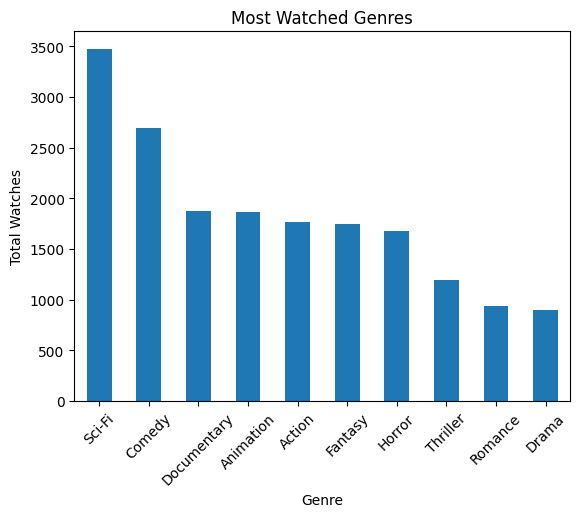

In [11]:
genre_stats.plot(x="primary_genre", y="total_watches", kind="bar", legend=False)
plt.title("Most Watched Genres")
plt.xlabel("Genre")
plt.ylabel("Total Watches")
plt.xticks(rotation=45)
plt.show()


## 3. Recommendation 1: Popularity-Based

It means to recommend what many people already like.

This is useful for:
- New users
- Home page trending section
- Cold-start situations


In [12]:
popular_movies = (
    ratings.groupby("movie_id")
    .agg(num_ratings=("rating", "count"), avg_rating=("rating", "mean"))
    .reset_index()
    .merge(movies, on="movie_id")
)

# Avoid recommending a movie with only a few ratings
popular_movies = popular_movies[popular_movies["num_ratings"] >= 50]

popular_movies["popularity_score"] = (
    popular_movies["avg_rating"] * 0.7 +
    np.log1p(popular_movies["num_ratings"]) * 0.3
)

popular_movies = popular_movies.sort_values("popularity_score", ascending=False)

popular_movies[["movie_id", "title", "primary_genre", "num_ratings", "avg_rating", "popularity_score"]].head(10)


,movie_id,title,primary_genre,num_ratings,avg_rating,popularity_score
57,158,Wedding Season,Documentary,336,3.657738,4.306442
1,102,City of Echoes,Horror,338,3.642012,4.297208
55,156,The Great Escape Plan,Romance,312,3.660256,4.286040
20,121,Desert Bloom,Thriller,292,3.671233,4.273915
29,130,Wild Earth,Action,305,3.652459,4.273797
48,149,Backstage Pass,Thriller,309,3.637540,4.267250
24,125,Mind Games,Documentary,289,3.664360,4.266016
36,137,The Lost Recipe,Animation,314,3.627389,4.264944
45,146,Medical Miracles,Thriller,319,3.617555,4.262785
54,155,Cyber City,Animation,297,3.646465,4.261653


In [13]:
def recommend_popular_movies(top_n=10):
    return popular_movies[["movie_id", "title", "primary_genre", "avg_rating", "num_ratings", "popularity_score"]].head(top_n)

recommend_popular_movies(10)


,movie_id,title,primary_genre,avg_rating,num_ratings,popularity_score
57,158,Wedding Season,Documentary,3.657738,336,4.306442
1,102,City of Echoes,Horror,3.642012,338,4.297208
55,156,The Great Escape Plan,Romance,3.660256,312,4.286040
20,121,Desert Bloom,Thriller,3.671233,292,4.273915
29,130,Wild Earth,Action,3.652459,305,4.273797
48,149,Backstage Pass,Thriller,3.637540,309,4.267250
24,125,Mind Games,Documentary,3.664360,289,4.266016
36,137,The Lost Recipe,Animation,3.627389,314,4.264944
45,146,Medical Miracles,Thriller,3.617555,319,4.262785
54,155,Cyber City,Animation,3.646465,297,4.261653


## 4. Recommendation 2: Content-Based

It means, If you liked Action + Sci-Fi movies, recommend more Action + Sci-Fi movies.

Here, we use movie features:
- Primary genre
- Secondary genre
- Content type
- Maturity rating
- Release year


In [14]:
movies_content = movies.copy()

movies_content["content_features"] = (
    movies_content["primary_genre"].astype(str) + " " +
    movies_content["secondary_genre"].astype(str) + " " +
    movies_content["content_type"].astype(str) + " " +
    movies_content["maturity_rating"].astype(str) + " " +
    movies_content["release_year"].astype(str)
)

movies_content[["movie_id", "title", "content_features"]].head()


,movie_id,title,content_features
0,101,Shadow Protocol,Comedy Action Movie PG 2019
1,102,City of Echoes,Horror Comedy Series G 2024
2,103,Neon Warriors,Sci-Fi Fantasy Movie R 2024
3,104,Love in Autumn,Horror Animation Series R 2018
4,105,The Last Algorithm,Action Sci-Fi Series PG-13 2021


In [15]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies_content["content_features"])

content_similarity = cosine_similarity(tfidf_matrix)

content_similarity_df = pd.DataFrame(
    content_similarity,
    index=movies_content["movie_id"],
    columns=movies_content["movie_id"]
)

content_similarity_df.head()


movie_id,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160
movie_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,1.000000,0.196478,0.090748,0.000000,0.320602,0.195034,0.000000,0.182994,0.618711,0.550420,0.086403,0.093937,0.088764,0.299334,0.499142,0.097511,0.097171,0.068641,0.408074,0.600066,0.175132,0.088199,0.092884,0.087929,0.355120,0.378630,0.000000,0.000000,0.091977,0.410417,0.101494,0.259235,0.358073,0.066421,0.289565,0.271743,0.272268,0.096701,0.295580,0.086796,0.224586,0.090748,0.098175,0.164416,0.595821,0.190099,0.408074,0.603507,0.165946,0.349873,0.000000,0.367998,0.098984,0.168151,0.182949,0.174207,0.305988,0.478813,0.440577,0.091094
102,0.196478,1.000000,0.339196,0.432938,0.102658,0.307511,0.129436,0.288529,0.172134,0.293112,0.000000,0.108811,0.000000,0.632332,0.000000,0.415322,0.000000,0.256564,0.000000,0.319550,0.000000,0.000000,0.000000,0.000000,0.169178,0.475020,0.088170,0.113339,0.000000,0.000000,0.775341,0.265064,0.114657,0.000000,0.189527,0.000000,0.120489,0.112012,0.130805,0.353632,0.146997,0.339196,0.445557,0.000000,0.197090,0.000000,0.000000,0.199632,0.000000,0.112031,0.125243,0.175313,0.114657,0.000000,0.000000,0.000000,0.312868,0.000000,0.000000,0.000000
103,0.090748,0.339196,1.000000,0.000000,0.288331,0.000000,0.211752,0.000000,0.079504,0.000000,0.423040,0.305611,0.434602,0.335117,0.090748,0.495355,0.316660,0.330419,0.320046,0.000000,0.258783,0.431833,0.302690,0.430513,0.078139,0.000000,0.247639,0.318328,0.660430,0.074617,0.323256,0.296456,0.000000,0.476923,0.439776,0.063737,0.000000,0.000000,0.213991,0.282848,0.067894,1.000000,0.186040,0.365017,0.091031,0.084007,0.320046,0.463224,0.368414,0.000000,0.000000,0.080973,0.000000,0.373309,0.080847,0.076984,0.000000,0.087052,0.080101,0.296854
104,0.000000,0.432938,0.000000,1.000000,0.091954,0.109686,0.115941,0.323577,0.000000,0.104550,0.000000,0.097465,0.238026,0.109170,0.000000,0.318102,0.000000,0.000000,0.000000,0.113980,0.000000,0.000000,0.000000,0.000000,0.000000,0.425491,0.078977,0.101521,0.000000,0.205309,0.412593,0.094546,0.102702,0.000000,0.000000,0.330541,0.339329,0.100333,0.117167,0.316760,0.000000,0.000000,0.399100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100350,0.112184,0.000000,0.322905,0.000000,0.641721,0.000000,0.111597,0.000000,0.220397,0.244273
105,0.320602,0.102658,0.288331,0.091954,1.000000,0.101903,0.107714,0.095613,0.417025,0.316211,0.274523,0.542389,0.282026,0.184505,0.088626,0.306000,0.000000,0.000000,0.000000,0.192635,0.208112,0.280230,0.000000,0.279373,0.076311,0.183538,0.536060,0.352228,0.292236,0.391391,0.177974,0.526142,0.515199,0.211035,0.285384,0.162930,0.315252,0.502480,0.342245,0.000000,0.000000,0.288331,0.172154,0.741621,0.232698,0.082041,0.000000,0.300600,0.436270,0.503400,0.104224,0.217739,0.310620,0.442067,0.078956,0.207013,0.188606,0.085016,0.215395,0.000000


In [16]:
def recommend_similar_movies(movie_title, top_n=5):
    movie_row = movies_content[movies_content["title"].str.lower() == movie_title.lower()]

    if movie_row.empty:
        return f"Movie '{movie_title}' not found."

    movie_id = movie_row["movie_id"].iloc[0]

    similar_scores = (
        content_similarity_df[movie_id]
        .sort_values(ascending=False)
        .drop(movie_id)
        .head(top_n)
        .reset_index()
    )

    similar_scores.columns = ["movie_id", "similarity_score"]

    return similar_scores.merge(movies, on="movie_id")[[
        "movie_id", "title", "primary_genre", "secondary_genre", "content_type", "similarity_score"
    ]]

recommend_similar_movies("Galaxy Riders", top_n=5)


,movie_id,title,primary_genre,secondary_genre,content_type,similarity_score
0,154,Love & Logic,Sci-Fi,Thriller,Movie,0.659224
1,156,The Great Escape Plan,Romance,Documentary,Movie,0.619290
2,144,Penguin Planet,Sci-Fi,Romance,Movie,0.565799
3,148,The Final Clue,Comedy,Sci-Fi,Movie,0.441040
4,129,The Startup,Fantasy,Sci-Fi,Movie,0.428769


## 5. Recommendation 3: Collaborative Filtering

It means, Users who behaved similarly in the past may like similar movies in the future.

Example:
- User A likes Movie 1 and Movie 2
- User B likes Movie 1, Movie 2, and Movie 3
- Recommend Movie 3 to User A

We build a user-item matrix where:
- Rows = users
- Columns = movies
- Values = ratings


In [17]:
user_item_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

user_item_matrix.head()


movie_id,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,3.0,3.0,2.0,NaN,3.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,4.0,3.0,3.0,2.0,5.0,NaN,NaN,5.0,NaN,NaN,2.0,NaN,NaN,4.0,NaN,3.0,NaN,NaN,3.0,NaN,2.0,2.0,NaN,4.0,5.0,NaN,3.0,3.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,4.0,NaN,1.0,NaN,NaN,NaN,3.0,NaN
2,NaN,NaN,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,5.0,NaN,1.0,5.0,NaN,2.0,NaN,NaN,4.0,3.0,NaN,NaN,NaN,3.0,NaN,3.0,5.0,4.0,NaN,4.0,3.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,2.0,4.0,NaN,NaN,NaN,NaN,NaN,3.0,4.0,3.0,NaN,4.0,NaN,NaN,NaN,5.0
3,4.0,4.0,NaN,5.0,NaN,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,4.0,5.0,NaN,2.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,4.0,NaN,4.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN
5,NaN,5.0,2.0,5.0,1.0,NaN,4.0,4.0,NaN,NaN,NaN,NaN,2.0,3.0,NaN,NaN,NaN,NaN,3.0,NaN,5.0,NaN,NaN,4.0,NaN,4.0,NaN,5.0,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,4.0,NaN,NaN,3.0,2.0,NaN,4.0,NaN,2.0,3.0,NaN,NaN,1.0,NaN,4.0,NaN,NaN,NaN,3.0,2.0,NaN


In [18]:
# Fill missing ratings with 0 for similarity calculation
user_item_filled = user_item_matrix.fillna(0)

user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

user_similarity_df.head()


user_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,...,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.437634,0.357255,0.052902,0.345333,0.421477,0.330975,0.299349,0.423871,0.227601,0.330176,0.330436,0.365693,0.249651,0.319147,0.422170,0.208591,0.452356,0.457927,0.379760,0.239612,0.256566,0.319491,0.385618,0.283670,0.374148,0.152828,0.548815,0.328209,0.442587,0.283475,0.296695,0.282607,0.247729,0.330901,0.324414,0.107859,0.392669,0.592861,0.115640,0.492187,0.536703,0.217000,0.525948,0.346340,0.322042,0.409029,0.524826,0.107615,0.364053,...,0.260764,0.169080,0.243708,0.271816,0.489361,0.287995,0.202476,0.166723,0.316126,0.400864,0.362432,0.353186,0.248897,0.229289,0.390688,0.378048,0.234759,0.273917,0.287672,0.128751,0.294069,0.228216,0.268267,0.347788,0.162915,0.144177,0.214217,0.321906,0.299146,0.192117,0.473510,0.261454,0.406872,0.437634,0.395706,0.490560,0.253470,0.428433,0.245235,0.305383,0.458359,0.538287,0.612650,0.213184,0.437398,0.236318,0.387718,0.267017,0.454006,0.307513
2,0.437634,1.000000,0.212956,0.117218,0.382589,0.411562,0.353587,0.411964,0.427879,0.292271,0.456341,0.363034,0.418524,0.302515,0.325954,0.247778,0.211837,0.326843,0.451232,0.380148,0.307695,0.378402,0.562542,0.360782,0.311740,0.345427,0.239321,0.367348,0.300447,0.278392,0.323031,0.300993,0.228476,0.310346,0.366601,0.413635,0.225714,0.259447,0.492616,0.256233,0.397912,0.399621,0.247924,0.535188,0.517355,0.411878,0.368724,0.418406,0.156482,0.234880,...,0.283586,0.079824,0.371251,0.444012,0.371477,0.208331,0.455650,0.309660,0.289477,0.364669,0.278843,0.361716,0.160854,0.389444,0.410057,0.279572,0.311115,0.329630,0.556112,0.371617,0.352945,0.306065,0.248486,0.229704,0.310550,0.191677,0.254279,0.370112,0.262850,0.000000,0.273063,0.147912,0.345645,0.398034,0.361678,0.170562,0.294316,0.211052,0.274162,0.501917,0.372696,0.399832,0.287729,0.259993,0.432968,0.356654,0.223978,0.203379,0.429273,0.216540
3,0.357255,0.212956,1.000000,0.070553,0.290691,0.268559,0.276394,0.197347,0.324911,0.095955,0.231865,0.364572,0.252222,0.204311,0.108827,0.581315,0.094838,0.364837,0.275466,0.417650,0.158461,0.433938,0.186762,0.430719,0.419371,0.062810,0.064139,0.158032,0.254944,0.230188,0.203269,0.207048,0.233366,0.291111,0.352773,0.299064,0.148208,0.077435,0.261106,0.243022,0.304821,0.490569,0.253700,0.274476,0.195330,0.385858,0.315796,0.212821,0.494173,0.327146,...,0.548160,0.264165,0.241755,0.148300,0.286768,0.314255,0.294584,0.112365,0.144316,0.580706,0.194078,0.071701,0.310391,0.327463,0.362739,0.057753,0.372897,0.230182,0.230622,0.218130,0.047538,0.279607,0.172758,0.204346,0.115027,0.075515,0.146928,0.073519,0.191351,0.107994,0.320037,0.242804,0.331322,0.287169,0.137387,0.201208,0.234031,0.197017,0.053519,0.172107,0.235786,0.284785,0.465052,0.251383,0.207514,0.168402,0.314281,0.169962,0.416822,0.153558
4,0.052902,0.117218,0.070553,1.000000,0.146672,0.177851,0.156193,0.345077,0.138865,0.367387,0.269979,0.224378,0.410278,0.257720,0.269060,0.121752,0.095704,0.253386,0.256970,0.400060,0.107937,0.354910,0.207314,0.300912,0.000000,0.322197,0.271845,0.245506,0.000000,0.211793,0.080266,0.250725,0.201854,0.239211,0.232443,0.332589,0.435485,0.000000,0.070788,0.254673,0.109858,0.080589,0.396825,0.264392,0.205683,0.286820,0.293184,0.187430,0.355497,0.014149,...,0.177350,0.437947,0.091486,0.448962,0.199576,0.167889,0.181151,0.000000,0.298371,0.108449,0.315946,0.101749,0.163138,0.044555,0.175478,0.218549,0.323946,0.260018,0.416970,0.167889,0.203882,0.317429,0.305086,0.382964,0.221602,0.038102,0.262841,0.309125,0.477065,0.086542,0.309339,0.073506,0.255775,0.297930,0.106952,0.408006,0.305944,0.247677,0.243035,0.227259,0.0

In [19]:
def recommend_user_based(user_id, top_n=5):
    if user_id not in user_item_matrix.index:
        return "User not found."

    # Users most similar to selected user
    similar_users = (
        user_similarity_df[user_id]
        .sort_values(ascending=False)
        .drop(user_id)
        .head(20)
    )

    # Movies already watched by selected user
    watched_movies = set(ratings[ratings["user_id"] == user_id]["movie_id"])

    # Ratings from similar users
    similar_user_ids = similar_users.index
    candidate_ratings = ratings[
        (ratings["user_id"].isin(similar_user_ids)) &
        (~ratings["movie_id"].isin(watched_movies))
    ]

    # Weighted score = rating * similarity
    candidate_ratings = candidate_ratings.merge(
        similar_users.rename("similarity"),
        left_on="user_id",
        right_index=True
    )

    candidate_ratings["weighted_rating"] = candidate_ratings["rating"] * candidate_ratings["similarity"]

    recommendations = (
        candidate_ratings.groupby("movie_id")
        .agg(
            recommendation_score=("weighted_rating", "sum"),
            similar_users_who_watched=("user_id", "nunique"),
            avg_rating_from_similar_users=("rating", "mean")
        )
        .reset_index()
        .merge(movies, on="movie_id")
        .sort_values("recommendation_score", ascending=False)
        .head(top_n)
    )

    return recommendations[[
        "movie_id", "title", "primary_genre", "secondary_genre",
        "recommendation_score", "similar_users_who_watched", "avg_rating_from_similar_users"
    ]]

recommend_user_based(user_id=10, top_n=5)


,movie_id,title,primary_genre,secondary_genre,recommendation_score,similar_users_who_watched,avg_rating_from_similar_users
48,159,Deep Sea Monsters,Animation,Romance,16.410752,10,3.700000
25,131,Mystery Lane,Horror,Drama,15.830621,9,4.000000
31,137,The Lost Recipe,Animation,Action,14.950237,9,3.555556
49,160,Comedy Roadtrip,Animation,Fantasy,13.693142,7,4.285714
24,130,Wild Earth,Action,Animation,13.168990,7,4.142857


## 6. Recommendation 4: Item-Based Collaborative Filtering

It means, Recommend movies similar to the movies the user already liked.

This is very common because item similarities are often more stable than user similarities.


In [20]:
item_user_matrix = ratings.pivot_table(
    index="movie_id",
    columns="user_id",
    values="rating"
).fillna(0)

item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

item_similarity_df.head()


movie_id,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160
movie_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
101,1.000000,0.305529,0.232652,0.320262,0.333191,0.333447,0.242919,0.335765,0.480069,0.339046,0.257980,0.236572,0.230291,0.346700,0.284469,0.272548,0.263583,0.276539,0.251836,0.294018,0.256073,0.271062,0.250279,0.222273,0.323300,0.291025,0.235557,0.240591,0.233208,0.368889,0.308488,0.314604,0.360710,0.245834,0.317025,0.371195,0.346148,0.264887,0.356138,0.287717,0.284438,0.262524,0.281089,0.230645,0.438985,0.270194,0.256525,0.309032,0.254907,0.441150,0.245382,0.319965,0.294087,0.258311,0.262435,0.253333,0.293785,0.303311,0.268952,0.237750
102,0.305529,1.000000,0.269554,0.449618,0.284175,0.358968,0.278694,0.339381,0.313163,0.364554,0.293581,0.261293,0.308870,0.356106,0.328237,0.277855,0.279437,0.289496,0.295224,0.349765,0.295266,0.249672,0.287684,0.299695,0.343041,0.450765,0.300417,0.279866,0.265334,0.314393,0.440886,0.330276,0.269682,0.272154,0.346135,0.307292,0.331063,0.306924,0.312827,0.466931,0.302071,0.203814,0.464383,0.278673,0.295755,0.306838,0.312703,0.333535,0.314707,0.272836,0.312669,0.320861,0.326184,0.290699,0.303477,0.268811,0.303926,0.303429,0.310585,0.334170
103,0.232652,0.269554,1.000000,0.313186,0.333361,0.251910,0.321723,0.275176,0.256602,0.214547,0.313788,0.269468,0.305993,0.222028,0.254959,0.304378,0.340001,0.266895,0.321889,0.264193,0.326010,0.351281,0.327434,0.295053,0.260138,0.232830,0.286241,0.340286,0.435816,0.245335,0.247870,0.261129,0.250473,0.410103,0.314598,0.230522,0.224359,0.259636,0.372469,0.320295,0.256798,0.370754,0.322721,0.307397,0.241158,0.272046,0.330724,0.322464,0.287873,0.267776,0.237137,0.255488,0.277023,0.303601,0.285010,0.258947,0.238542,0.276617,0.301511,0.350706
104,0.320262,0.449618,0.313186,1.000000,0.262027,0.326247,0.280158,0.377695,0.255834,0.283108,0.281473,0.286610,0.347482,0.302247,0.275002,0.376991,0.296332,0.281251,0.319042,0.278946,0.302365,0.253184,0.326881,0.301108,0.281039,0.478127,0.254383,0.300953,0.302723,0.317427,0.446481,0.235002,0.282308,0.270072,0.276032,0.296324,0.388840,0.319337,0.295777,0.476631,0.231206,0.279597,0.460921,0.309922,0.258597,0.296389,0.322118,0.293797,0.243380,0.275258,0.301323,0.284797,0.371743,0.303291,0.326761,0.289431,0.290974,0.310564,0.340284,0.343843
105,0.333191,0.284175,0.333361,0.262027,1.000000,0.290962,0.255115,0.287792,0.347929,0.247268,0.309018,0.285774,0.330928,0.252480,0.226111,0.292022,0.227288,0.257710,0.250745,0.229768,0.278876,0.323468,0.252071,0.290220,0.254217,0.271830,0.318439,0.304305,0.288319,0.391347,0.270776,0.294537,0.333606,0.294216,0.303613,0.333592,0.355349,0.239139,0.374862,0.236902,0.254899,0.218187,0.264052,0.264375,0.366307,0.298112,0.221973,0.333316,0.334417,0.382510,0.258189,0.278863,0.262334,0.309042,0.264246,0.253612,0.247990,0.255209,0.315255,0.252407


In [21]:
def recommend_item_based(user_id, top_n=5):
    if user_id not in ratings["user_id"].unique():
        return "User not found."

    user_history = ratings[ratings["user_id"] == user_id]
    liked_movies = user_history[user_history["rating"] >= 4]["movie_id"].tolist()
    watched_movies = set(user_history["movie_id"])

    scores = {}

    for movie_id in liked_movies:
        similar_items = item_similarity_df[movie_id].sort_values(ascending=False).drop(movie_id)

        for candidate_movie_id, similarity in similar_items.items():
            if candidate_movie_id not in watched_movies:
                scores[candidate_movie_id] = scores.get(candidate_movie_id, 0) + similarity

    if not scores:
        return "No recommendations found."

    recs = (
        pd.DataFrame(scores.items(), columns=["movie_id", "recommendation_score"])
        .sort_values("recommendation_score", ascending=False)
        .head(top_n)
        .merge(movies, on="movie_id")
    )

    return recs[[
        "movie_id", "title", "primary_genre", "secondary_genre", "recommendation_score"
    ]]

recommend_item_based(user_id=10, top_n=5)


,movie_id,title,primary_genre,secondary_genre,recommendation_score
0,104,Love in Autumn,Horror,Animation,2.038077
1,102,City of Echoes,Horror,Comedy,2.018294
2,131,Mystery Lane,Horror,Drama,2.001726
3,152,Neighborhood Heroes,Comedy,Drama,1.999652
4,108,Laugh Track Live,Animation,Comedy,1.985883


## 7. Rating Prediction and Evaluation

Now we create a simple user-based rating predictor.

Goal: Predict what rating a user might give to a movie they have not watched.

Then we evaluate using:

- **RMSE**: Root Mean Squared Error
- **MAE**: Mean Absolute Error

Lower is better.


In [22]:
train, test = train_test_split(
    ratings[["user_id", "movie_id", "rating"]],
    test_size=0.2,
    random_state=42
)

train_matrix = train.pivot_table(index="user_id", columns="movie_id", values="rating").fillna(0)

train_user_similarity = cosine_similarity(train_matrix)
train_user_similarity_df = pd.DataFrame(
    train_user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

movie_avg_rating = train.groupby("movie_id")["rating"].mean()
global_avg_rating = train["rating"].mean()


In [23]:
def predict_rating(user_id, movie_id, k=20):
    # If user or movie is new, use fallback average
    if user_id not in train_matrix.index:
        return global_avg_rating

    if movie_id not in train_matrix.columns:
        return global_avg_rating

    similarities = train_user_similarity_df[user_id].sort_values(ascending=False).drop(user_id)
    top_users = similarities.head(k)

    numerator = 0
    denominator = 0

    for similar_user_id, similarity in top_users.items():
        rating = train_matrix.loc[similar_user_id, movie_id]
        if rating > 0:
            numerator += similarity * rating
            denominator += abs(similarity)

    if denominator == 0:
        return movie_avg_rating.get(movie_id, global_avg_rating)

    return numerator / denominator


In [24]:
test = test.copy()
test["predicted_rating"] = test.apply(
    lambda row: predict_rating(row["user_id"], row["movie_id"]),
    axis=1
)

rmse = np.sqrt(mean_squared_error(test["rating"], test["predicted_rating"]))
mae = mean_absolute_error(test["rating"], test["predicted_rating"])

print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))

test.head()


RMSE: 1.1448
MAE: 0.9215


,user_id,movie_id,rating,predicted_rating
10349,568,127,4,3.856884
15255,841,152,5,4.272021
15100,832,101,3,2.685098
13631,749,144,4,4.248543
2602,137,130,5,2.000000


## 8. Final Hybrid Recommender

A hybrid recommender combines multiple signals.

Here we combine:

1. Collaborative score
2. Content similarity score
3. Popularity score


In [25]:
# Normalize popularity score
pop_norm = popular_movies[["movie_id", "popularity_score"]].copy()
pop_norm["popularity_score_norm"] = (
    (pop_norm["popularity_score"] - pop_norm["popularity_score"].min()) /
    (pop_norm["popularity_score"].max() - pop_norm["popularity_score"].min())
)
pop_score_map = dict(zip(pop_norm["movie_id"], pop_norm["popularity_score_norm"]))


In [26]:
def recommend_hybrid(user_id, top_n=10):
    if user_id not in ratings["user_id"].unique():
        return "User not found."

    user_history = ratings[ratings["user_id"] == user_id]
    watched_movies = set(user_history["movie_id"])
    liked_movies = user_history[user_history["rating"] >= 4]["movie_id"].tolist()

    candidate_movies = set(movies["movie_id"]) - watched_movies
    results = []

    # Collaborative recommendations
    item_scores = {}
    for movie_id in liked_movies:
        if movie_id in item_similarity_df.index:
            similar_items = item_similarity_df[movie_id].sort_values(ascending=False).drop(movie_id)
            for candidate_movie_id, similarity in similar_items.items():
                if candidate_movie_id in candidate_movies:
                    item_scores[candidate_movie_id] = item_scores.get(candidate_movie_id, 0) + similarity

    max_item_score = max(item_scores.values()) if item_scores else 1

    # User favorite genres for content preference
    fav_genres = set(users[users["user_id"] == user_id][["favorite_genre_1", "favorite_genre_2"]].iloc[0].values)

    for movie_id in candidate_movies:
        movie = movies[movies["movie_id"] == movie_id].iloc[0]

        collaborative_score = item_scores.get(movie_id, 0) / max_item_score

        content_score = 0
        if movie["primary_genre"] in fav_genres:
            content_score += 0.6
        if movie["secondary_genre"] in fav_genres:
            content_score += 0.4

        popularity_score = pop_score_map.get(movie_id, 0)

        final_score = (
            0.50 * collaborative_score +
            0.30 * content_score +
            0.20 * popularity_score
        )

        results.append({
            "movie_id": movie_id,
            "title": movie["title"],
            "primary_genre": movie["primary_genre"],
            "secondary_genre": movie["secondary_genre"],
            "content_type": movie["content_type"],
            "hybrid_score": final_score,
            "collaborative_score": collaborative_score,
            "content_score": content_score,
            "popularity_score": popularity_score
        })

    return pd.DataFrame(results).sort_values("hybrid_score", ascending=False).head(top_n)

recommend_hybrid(user_id=10, top_n=10)


,movie_id,title,primary_genre,secondary_genre,content_type,hybrid_score,collaborative_score,content_score,popularity_score
22,152,Neighborhood Heroes,Comedy,Drama,Movie,0.946810,0.981147,1.0,0.781185
13,141,Moonlight Letters,Comedy,Drama,Movie,0.890201,0.962545,1.0,0.544640
29,102,City of Echoes,Horror,Comedy,Series,0.808704,0.990293,0.4,0.967788
37,110,Broken Compass,Comedy,Documentary,Series,0.774391,0.861954,0.6,0.817070
35,108,Laugh Track Live,Animation,Comedy,Series,0.762540,0.974390,0.4,0.776725
43,118,The Marble Crown,Drama,Documentary,Movie,0.754091,0.924149,0.6,0.560082
3,131,Mystery Lane,Horror,Drama,Series,0.749728,0.982164,0.4,0.693230
28,101,Shadow Protocol,Comedy,Action,Movie,0.747487,0.842191,0.6,0.731955
18,146,Medical Miracles,Thriller,Drama,Movie,0.740500,0.901924,0.4,0.847693
24,157,Planet Rescue,Comedy,Documentary,Series,0.733989,0.852012,0.6,0.639912


## 9. Explain Recommendations for One User


In [27]:
def explain_user_profile(user_id):
    user = users[users["user_id"] == user_id]
    if user.empty:
        return "User not found."

    user_info = user.iloc[0]
    user_history = ratings[ratings["user_id"] == user_id].merge(movies, on="movie_id")

    print("User Profile")
    print("------------")
    print("User ID:", user_id)
    print("Age:", user_info["age"])
    print("Country:", user_info["country"])
    print("Plan:", user_info["subscription_plan"])
    print("Device:", user_info["primary_device"])
    print("Favorite genres:", user_info["favorite_genre_1"], "and", user_info["favorite_genre_2"])

    print("\nTop watched/liked movies:")
    display(user_history.sort_values(["rating", "completion_rate"], ascending=False)[[
        "title", "primary_genre", "secondary_genre", "rating", "completion_rate"
    ]].head(10))

    print("\nHybrid recommendations:")
    display(recommend_hybrid(user_id, top_n=10))

explain_user_profile(10)


User Profile
------------
User ID: 10
Age: 46
Country: Canada
Plan: Premium
Device: Laptop
Favorite genres: Drama and Comedy

Top watched/liked movies:


,title,primary_genre,secondary_genre,rating,completion_rate
3,Cyber City,Animation,Drama,5,0.76
5,Arctic Secrets,Animation,Drama,4,0.95
1,The Final Clue,Comedy,Sci-Fi,4,0.93
4,Mind Games,Documentary,Comedy,4,0.92
0,Cooking with Chaos,Sci-Fi,Drama,4,0.82
2,Robot Heart,Horror,Drama,4,0.64
6,The Comedy Club,Fantasy,Romance,3,0.63
8,Love & Logic,Sci-Fi,Thriller,3,0.33
7,The Quiet Witness,Sci-Fi,Animation,3,0.27
9,Supernova Kids,Documentary,Fantasy,1,0.15



Hybrid recommendations:


,movie_id,title,primary_genre,secondary_genre,content_type,hybrid_score,collaborative_score,content_score,popularity_score
22,152,Neighborhood Heroes,Comedy,Drama,Movie,0.946810,0.981147,1.0,0.781185
13,141,Moonlight Letters,Comedy,Drama,Movie,0.890201,0.962545,1.0,0.544640
29,102,City of Echoes,Horror,Comedy,Series,0.808704,0.990293,0.4,0.967788
37,110,Broken Compass,Comedy,Documentary,Series,0.774391,0.861954,0.6,0.817070
35,108,Laugh Track Live,Animation,Comedy,Series,0.762540,0.974390,0.4,0.776725
43,118,The Marble Crown,Drama,Documentary,Movie,0.754091,0.924149,0.6,0.560082
3,131,Mystery Lane,Horror,Drama,Series,0.749728,0.982164,0.4,0.693230
28,101,Shadow Protocol,Comedy,Action,Movie,0.747487,0.842191,0.6,0.731955
18,146,Medical Miracles,Thriller,Drama,Movie,0.740500,0.901924,0.4,0.847693
24,157,Planet Rescue,Comedy,Documentary,Series,0.733989,0.852012,0.6,0.639912


## 10. Business Interpretation

For a streaming company, recommendations can improve:

- Watch time
- User engagement
- Retention
- Subscription renewals
- Content discovery